# Peer-to-peer Loan Data Analysis 💰 - II

### 📊 Exploratory Data Analysis & Visualisations using `Seaborn`


**Seaborn** is a visualization tool that we can import into our code that works well with Matplotlib. 

Its main strengths are:
* Improved visual appeal
* Reduced need to manipulate the data using grouping and summarization, and
* Its additional plot types that aren't available through Matplotlib.

Seaborn automatically summarizes our data, rather than making us go through the groupby and summarization steps manually.

## Scenario - 1: 
### `Grouped Column Chart`

**Goal:** Identify key characteristics of loans from states with highest average loan amount:
- District of Columbia
- Alaska
- Hawaii

**Task:** Plot the **Loan Amounts** and **Interest Rates** by **Grade** across these three states using a **grouped bar chart**.

### 1. Plotting the Loan Amounts by Grades

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
df= pd.read_csv("loan_data.csv")

In [4]:
df.head()

,emp_title,emp_length,state,homeownership,debt_to_income,annual_income,open_credit_lines,total_credit_limit,total_credit_utilized,total_debit_limit,loan_amount,interest_rate,installment,grade,balance,paid_interest
0,administrative assistant,0,FL,RENT,22.51,32000.0,4,22984,18420,5000,2500,7.96,78.30,A,2326.16,31.65
1,sole proprietor,10,MN,OWN,2.99,45000.0,5,203255,1469,9000,12500,7.34,387.91,A,11559.92,218.55
2,pension ananlyst,10,MD,OWN,21.07,90000.0,19,154848,62112,79300,13000,7.35,403.49,A,11360.72,364.90
3,director of corporate operations,0,MN,MORTGAGE,12.28,130000.0,23,296496,77944,93600,17500,7.35,349.42,A,16273.90,470.99
4,dispatcher,3,TX,RENT,28.97,65000.0,28,156207,70381,50800,8000,7.96,250.55,A,7403.61,151.72


In [5]:
states = ["DC","AK","HI"]

In [6]:
filtered_df = df[df["state"].isin(states)]

In [7]:
filtered_df.sample(5)

,emp_title,emp_length,state,homeownership,debt_to_income,annual_income,open_credit_lines,total_credit_limit,total_credit_utilized,total_debit_limit,loan_amount,interest_rate,installment,grade,balance,paid_interest
2421,night shift associate,4,AK,RENT,20.68,22800.0,3,11500,8130,3500,10000,15.04,346.85,C,9327.09,359.28
44,management,10,DC,MORTGAGE,4.36,152000.0,6,560826,17408,65300,40000,7.34,798.49,A,38328.35,707.51
2664,jewelry consultant,1,HI,RENT,12.43,50000.0,7,27776,18753,2600,10000,18.06,254.27,D,0.00,475.63
601,forman,4,AK,RENT,15.27,90000.0,5,80384,53209,32500,36000,6.71,1106.81,A,33268.25,561.84
1490,management,5,DC,RENT,34.91,187000.0,22,330513,212441,91500,10000,11.98,332.05,B,9533.25,184.04


* From seaborn, we use `sns.barplot()`.
* The first argument is always the `DataFrame`. We do not need to group it in advance.
* On the `x-axis`, we want **state** and on the `y-axis`, we want **loan amount**.

* In order to separate out the loan amount by grade as well, we're going to use the `hue` named argument.
* The `hue` parameter in Seaborn is used to assign colors to different categories or data points, making it easier to distinguish between them visually. 
* Here, we use `hue='grade'` to color the bars differently based on the grade of loans, allowing for clear visual differentiation between categories like A, B, and C grades.

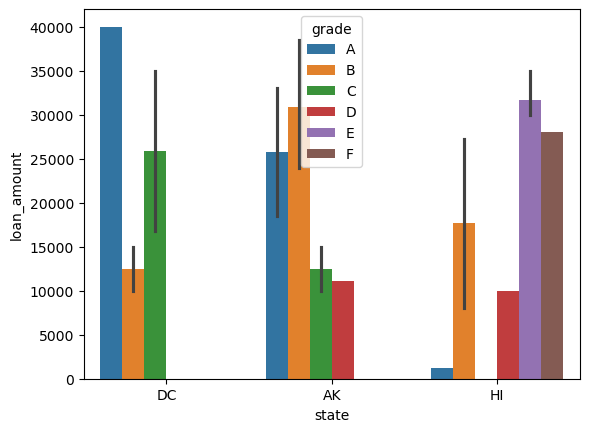

In [9]:
sns.barplot(
    filtered_df,
    x="state",
    y="loan_amount",
    hue="grade")
plt.show()

*There's no grouping, there's no mean, there's no stacking, they're just creating a bar plot. We get this nice bar plot where the mean loan amount has already been calculated, in this case across all states.*

* Since **Seaborn is built on top of matplotlib**, we can stack matplotlib and Seaborn commands together. So matplotlib or plot functions like ​title, xlabel, and ylabel work perfectly well with Seaborn.

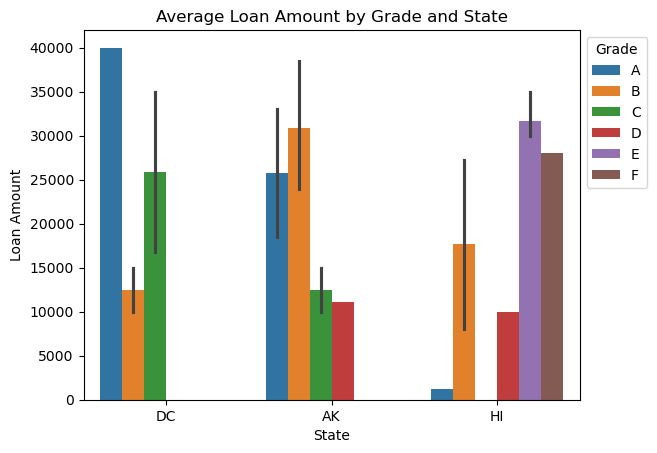

In [12]:
sns.barplot(
    filtered_df,
    x="state",
    y="loan_amount",
    hue="grade")

plt.title("Average Loan Amount by Grade and State")
plt.xlabel("State")
plt.ylabel("Loan Amount")
plt.legend(title="Grade", bbox_to_anchor=(1,1))
plt.show()

### 2. Plotting the Interest Rates by Grades

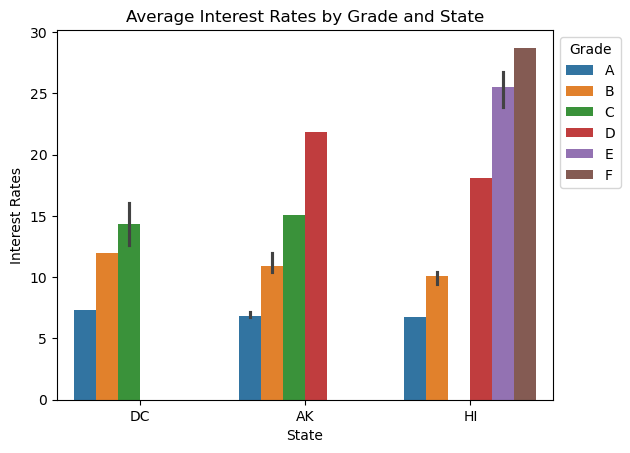

In [13]:
sns.barplot(
    filtered_df,
    x="state",
    y="interest_rate",  # we just change the values on the y-axis argument
    hue="grade")

plt.title("Average Interest Rates by Grade and State")
plt.xlabel("State")
plt.ylabel("Interest Rates")
plt.legend(title="Grade", bbox_to_anchor=(1,1))
plt.show()

* The default `estimator` is `np.mean`, which takes the mean of each group.

* So by default, this function plots the mean amount or the mean interest rate, but we can use other estimators as well. 

* `NumPy` provides the estimators. It turns out that way down under the hood, Seaborn, matplotlib, pandas, they're all operating on NumPy. So the mean, max, and standard deviation functions, those actually all come from NumPy.

* Our choice of estimator depends on what we're trying to communicate to our clients.

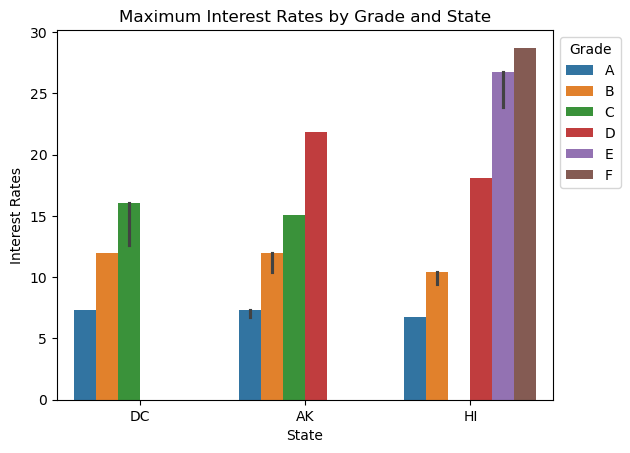

In [14]:
sns.barplot(
    filtered_df,
    x="state",
    y="interest_rate",
    hue="grade",
    estimator=np.max)   # gives us the highest interest rate for each group

plt.title("Maximum Interest Rates by Grade and State")
plt.xlabel("State")
plt.ylabel("Interest Rates")
plt.legend(title="Grade", bbox_to_anchor=(1,1))
plt.show()

### Themes and Palettes

Themes and Palettes give us more control of the visual style of our plots.

#### I. Changing the **Theme**:

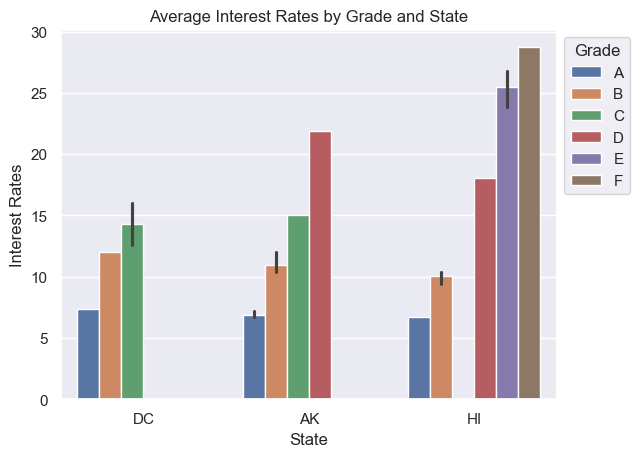

In [15]:
sns.set_theme()   # to change the default styling of the plot

sns.barplot(
    filtered_df,
    x="state",
    y="interest_rate",
    hue="grade")

plt.title("Average Interest Rates by Grade and State")
plt.xlabel("State")
plt.ylabel("Interest Rates")
plt.legend(title="Grade", bbox_to_anchor=(1,1))
plt.show()

*Each bar now has a white outline, plus a darker background behind the entire plot, and white or invisible spines.*

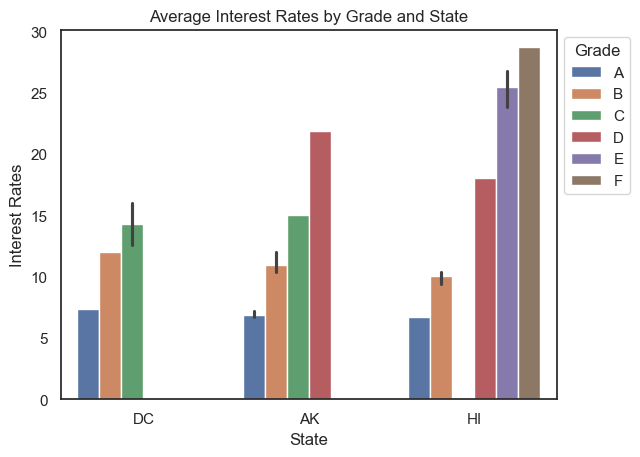

In [16]:
sns.set_theme(style="white")   # style argument to choose the style

sns.barplot(
    filtered_df,
    x="state",
    y="interest_rate",
    hue="grade")

plt.title("Average Interest Rates by Grade and State")
plt.xlabel("State")
plt.ylabel("Interest Rates")
plt.legend(title="Grade", bbox_to_anchor=(1,1))
plt.show()

*`White` returns our plot to the default matplotlib look.*

* If we create the same chart again in a new cell, the theme sticks.

* We have different options for the `style` named argument, ​which allows us to pick the right style for our plots. 

#### II. Changing the **Color Palette**:

* With `palette`, we can avoid manually selecting colors for our plots.

* Right now, we're using a `categorical palette` with many distinct colors, but a `diverging palette` like the green to red one will emphasize the inside colors. 

* We'll emphasize the insights in this chart. We add a new named argument to our plotting function, `palette`. The value of this argument should be the name of a color palette. 

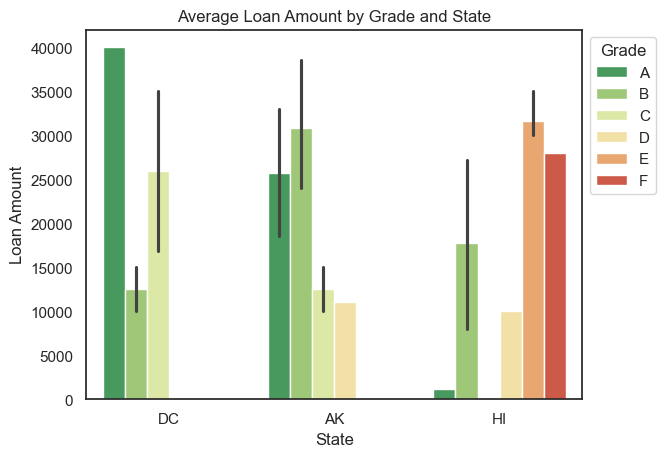

In [19]:
sns.barplot(
    filtered_df,
    x="state",
    y="loan_amount",
    hue="grade",
    palette="RdYlGn_r")

plt.title("Average Loan Amount by Grade and State")
plt.xlabel("State")
plt.ylabel("Loan Amount")
plt.legend(title="Grade", bbox_to_anchor=(1,1))
plt.savefig("avg_loan_amt_by_grade_and_state.png", bbox_inches="tight")

## Scenario - 2:
### `Box Plots`

Seaborn gives us some great options for **visualizing the distribution of our data.**
While **Box Plots** would have been challenging to make with Matplotlib, Seaborn makes them easier.

**Goal:**
* We are interested in characterizing the different features present in the dataset. It contains both:
    * Features of **each person**, like their **occupation** and **loan history**, and
    * Features of the **individual loans** in the dataset, like the **loan amount** and **interest rate.**

**Task:**
* Create Box plots to understand the distribution of interest rates by different grades.

### 1. Plotting the distribution of interest rates for all the loans

In [20]:
df.head()

,emp_title,emp_length,state,homeownership,debt_to_income,annual_income,open_credit_lines,total_credit_limit,total_credit_utilized,total_debit_limit,loan_amount,interest_rate,installment,grade,balance,paid_interest
0,administrative assistant,0,FL,RENT,22.51,32000.0,4,22984,18420,5000,2500,7.96,78.30,A,2326.16,31.65
1,sole proprietor,10,MN,OWN,2.99,45000.0,5,203255,1469,9000,12500,7.34,387.91,A,11559.92,218.55
2,pension ananlyst,10,MD,OWN,21.07,90000.0,19,154848,62112,79300,13000,7.35,403.49,A,11360.72,364.90
3,director of corporate operations,0,MN,MORTGAGE,12.28,130000.0,23,296496,77944,93600,17500,7.35,349.42,A,16273.90,470.99
4,dispatcher,3,TX,RENT,28.97,65000.0,28,156207,70381,50800,8000,7.96,250.55,A,7403.61,151.72


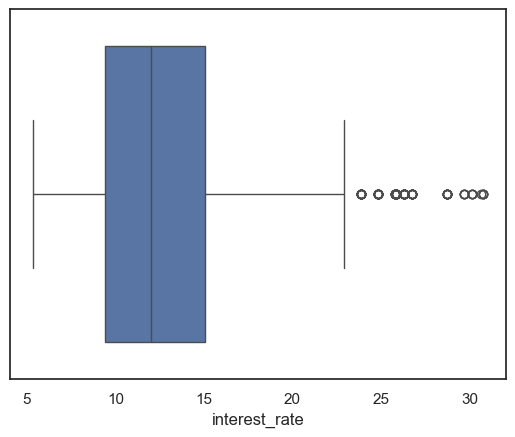

In [22]:
sns.boxplot(df, x="interest_rate")  # generates a horizontal boxplot
plt.show()

This graph shows the **skewed distribution of interest rate,** with the **median rate around 12%**. That's pretty high, so this distribution can help us communicate a typical interest rate for these loans.

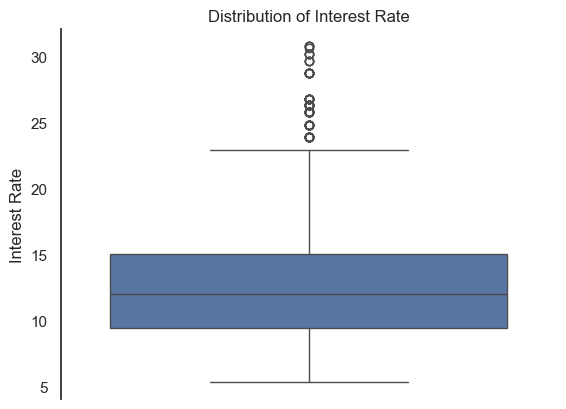

In [26]:
sns.boxplot(df, y="interest_rate")   # generates a vertical boxplot

plt.title("Distribution of Interest Rate", fontsize=12)
plt.ylabel("Interest Rate")
sns.despine(bottom=True)    # removes the spines
plt.show()

*Now you get this clean plot without any unnecessary boundaries, which increases our data-to-ink ratio.*

### Box plots for Segmented Data

* We can create box plots for **segmented data** as well, just by adding an x variable in addition to our y variable.

* For example, to segment interest rate by grade, we can add the named argument to boxplot, x equals grade.

/var/folders/6h/h489k5ln6r93tz_q7ssx2hj00000gn/T/ipykernel_3028/1991929802.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df, x="grade", y="interest_rate", palette="RdYlGn_r")


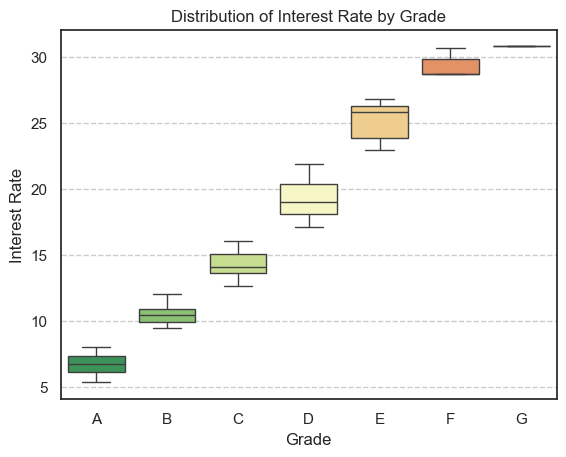

In [39]:
sns.boxplot(df, x="grade", y="interest_rate", palette="RdYlGn_r")

plt.title("Distribution of Interest Rate by Grade")
plt.xlabel("Grade")
plt.ylabel("Interest Rate")
plt.grid(axis="y", linestyle="--", color="grey", alpha=0.4)
plt.show()

* Now we see a very clear pattern where interest rates increase dramatically, with A-grade loans having interest rates in the single digits, and E, F, and G loans with interest rates in the 20% range. Add the bottom spine back in since we have data on that axis now. 

* We can share this graph with our clients so they can start to understand the profitability versus risk for each of these groups of loans. 

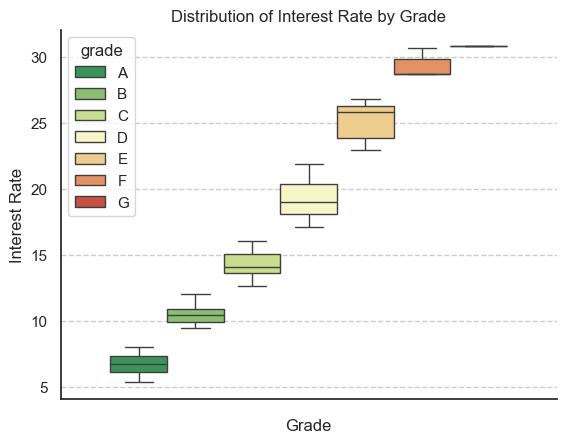

In [45]:
sns.boxplot(df, hue="grade", y="interest_rate", palette="RdYlGn_r")   # setting hue as per the warning received
sns.despine()
plt.title("Distribution of Interest Rate by Grade")
plt.xlabel("Grade")
plt.ylabel("Interest Rate")
plt.grid(axis="y", linestyle="--", color="grey", alpha=0.4)
plt.show()

*This version seems less readable though since we lose the double encoding of color and label. Now only color differentiates between the grades*

**Tip:** The orientation of this graph matches the graphs we made earlier, loan grade on x, interest rate on y. If we're presenting many graphs, our clients may benefit from seeing data laid out in a similar format each time, and a y-axis grid might be nice to help read values from the axis.

* Since, there is a lot of information here, we can make this graph larger. We can use `plot.figure` to create the figure with a specific size. It should come first. The `figsize` takes argumenst that are in inches

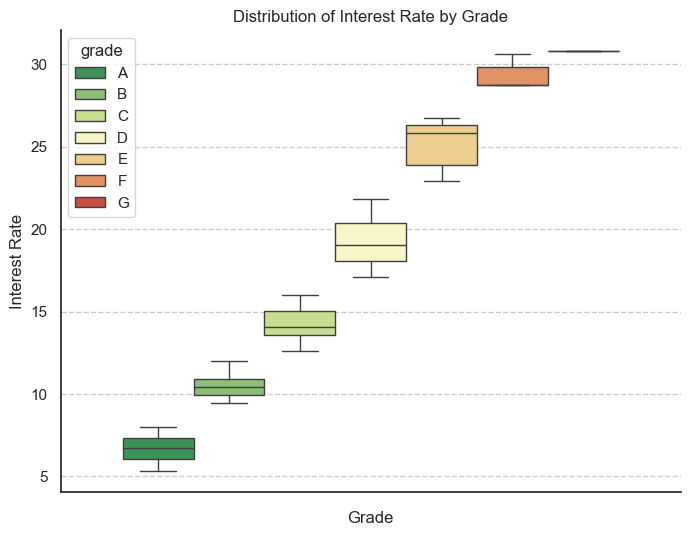

In [50]:
plt.figure(figsize=(8,6))    # changing the size

sns.boxplot(df, hue="grade", y="interest_rate", palette="RdYlGn_r")
sns.despine()
plt.title("Distribution of Interest Rate by Grade", fontsize=12)
plt.xlabel("Grade")
plt.ylabel("Interest Rate")
plt.grid(axis="y", linestyle="--", color="grey", alpha=0.4)
plt.savefig("dist_of_interest_rate_by_grade.png")

## Scenario-3: 
### `Histograms`

Histograms are a go-to plot type for visualizing the distributions of our features. Seaborn gives us great-looking plots out of the box, and we can use Matplotlib to further customize them. 

**Goal:**

* We are interested in characterizing the different features present in the dataset. It contains both:
    
    * Features of **each person**, like their **occupation** and **loan history**, and
    
    * Features of the **individual loans** in the dataset, like the **loan amount** and **interest rate.**

**Task:**

Based on some previous analysis, we know that the **loan amount** feature in our dataset has some interesting patterns. 
We want to visualize this data using a **histogram** to explain its unique properties to our clients. 
This visualization will help them identify and price common loan products based on what their competitors may offer.


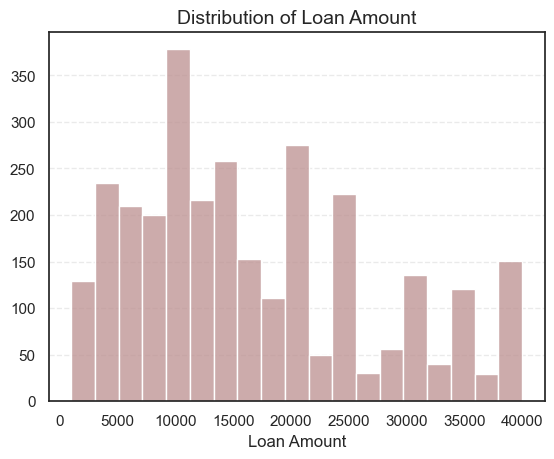

In [58]:
sns.histplot(df, x="loan_amount", color="RosyBrown")

plt.title("Distribution of Loan Amount", fontsize=14)
plt.xlabel("Loan Amount")
plt.ylabel("")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

*The values that make up the spikes in frequency are at round numbers, like 10,000, 20,000, 25,000, and so on.*

* This pattern is worth investigating further to help our clients understand the psychological factors involved in taking out loans of different sizes, as well as the demand for them. 

* To show the spikes more cleanly, we can add the `bins` argument to the histplot function. 

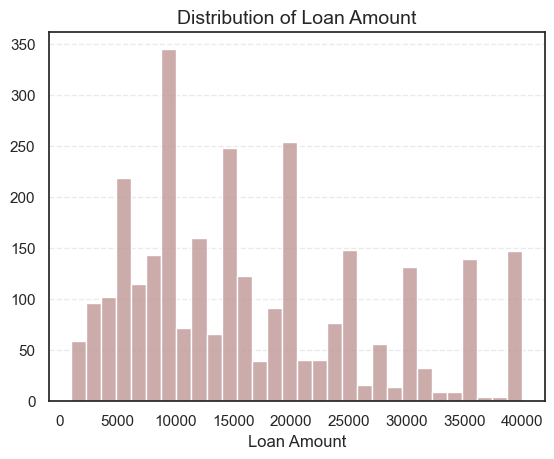

In [60]:
sns.histplot(df, x="loan_amount", color="RosyBrown", bins=30)
plt.title("Distribution of Loan Amount", fontsize=14)
plt.xlabel("Loan Amount")
plt.ylabel("")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

* Instead of setting the number of bins, we can also set the `binwidth` argument instead.

* For example, we are interested in having bins of size $5,000 to help with interpretability.

* Binwidth overrides bins, so we only need to use one of them.

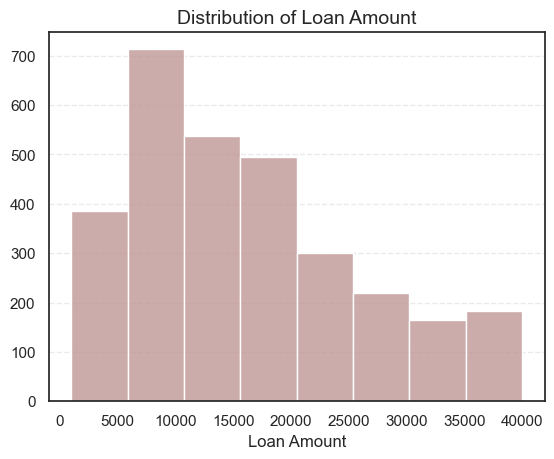

In [61]:
sns.histplot(df, x="loan_amount", color="RosyBrown", binwidth=5000)
plt.title("Distribution of Loan Amount", fontsize=14)
plt.xlabel("Loan Amount")
plt.ylabel("")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

* Now, that update does help with interpretability, but the ticks on the x-axis aren't showing. This issue comes from a setting that's part of the Seaborn theme we're using.

* **Sometimes issues are caused by our `theme`**. So we can try setting components of the theme to fix those issues. 

* In this case, we'll want to run `sns.set_style("ticks")` to show the ticks. Previously, our theme had invisible ticks, a feature intended to declutter the plot. 

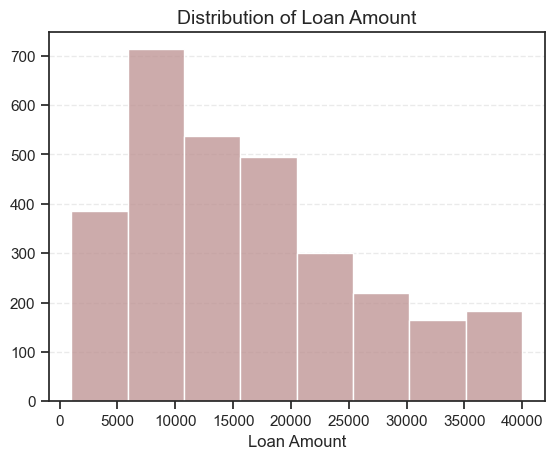

In [62]:
sns.set_style("ticks")

sns.histplot(df, x="loan_amount", color="RosyBrown", binwidth=5000)
plt.title("Distribution of Loan Amount", fontsize=14)
plt.xlabel("Loan Amount")
plt.ylabel("")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

*Now we can help our clients understand that, for example, loans in the $5,000 to $10,000 range are about twice as common as loans in the $20,000 to $25,000 range.*

* Finally, we can also add an **estimated density curve** to our histogram using the named argument `kde="true"`. **KDE** stands for **Kernel Density Estimate**. It tries to estimate a smooth curve showing the probability density of the distribution.

* So this is one option we have, if we want to communicate insights about the relative probabilities across the distribution, in addition to the frequencies visualized by the histogram.

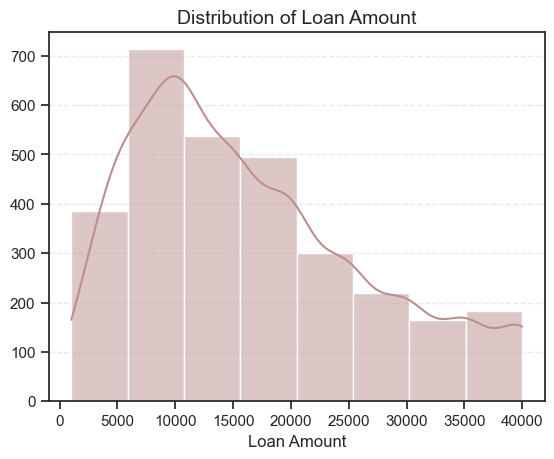

In [64]:
sns.histplot(df, x="loan_amount", color="RosyBrown", binwidth=5000, kde=True)

plt.title("Distribution of Loan Amount", fontsize=14)
plt.xlabel("Loan Amount")
plt.ylabel("")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.savefig("distribution_of_loan_amount")